# Optimise SplitGaussianWaveform on E/I SNN — real Allen VISp PSTH target

Like `28_04_26_optimise_splitgaussian_ei_snn.ipynb` but uses the cross-session
mean VISp PSTH (from Allen Neuropixels) as the optimisation target instead of
a synthetic waveform.

**Pre-requisite:** run the *Save cross-session mean PSTH* cell in
`28_04_26_allen_natural_scene_alllayers_spiketimes_vis.ipynb` to produce
`results/allen/visp_psths.pkl` (or fall back to `data/visp_mean_psth.npz`).

**Strategy**
1. Load the real target PSTH and align it to the SNN time grid.
2. Build a `RandomEINetwork` with a stim window matching the Allen stimulus duration.
3. Optimise a `SplitGaussianWaveform` to minimise MSE between the SNN PSTH
   and the real target.
4. Compare the optimised model PSTH against the data.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from designer_waveform.waveforms import (
    SplitGaussianWaveform,
    AsymBaselineSplitGaussianWaveform,
)
from designer_waveform.models import RandomEINetwork, load_config
from designer_waveform.optics import OpticsConfig, SigmoidPowerCurve

## 1. Load real target PSTH

In [ ]:
# ── Configurable selectors ───────────────────────────────────────────────
# SOURCE picks which file to load:
#   'own_pipeline_passive' → results from our Allen Neuropixels extraction
#                            (passive natural scene viewing)
#                            File: data/allen_visual_neuropixels_passive/visp_psths.pkl
#   'siegle_fig4d'         → hand-digitized from Siegle et al. 2021 Fig 4D
#                            (different dataset — do not conflate with own_pipeline_passive)
SOURCE        = 'own_pipeline_passive'

TARGET_LAYER  = 'all'      # 'all', 'VISp1', 'VISp2/3', 'VISp4', 'VISp5', 'VISp6a', 'VISp6b'
                           # Layer options only available for own_pipeline_passive.
                           # Check available keys: list(_allen['filtered'].keys())
USE_RF_FILTER = True       # own_pipeline_passive: True → RF p-value < 0.01 units only
                           # siegle_fig4d:         True → Change trace; False → Pre-change
STIM_DUR_MS   = 250.0      # natural-scene stimulus duration (ms)

import pickle
_path_map = {
    'own_pipeline_passive': Path('../data/allen_visual_neuropixels_passive/visp_psths.pkl'),
    'siegle_fig4d':         Path('../data/siegle2021_fig4d/siegle_2021_fig4d_v1.pkl'),
}
if SOURCE not in _path_map:
    raise ValueError(f'SOURCE={SOURCE!r} must be one of {list(_path_map)}')
ALLEN_PATH = _path_map[SOURCE]
with open(ALLEN_PATH, 'rb') as f:
    _allen = pickle.load(f)

_meta       = _allen['meta']
_filter_key = 'filtered' if USE_RF_FILTER else 'unfiltered'
if TARGET_LAYER not in _allen[_filter_key]:
    _avail = sorted(_allen[_filter_key].keys(), key=lambda x: (x != 'all', x))
    raise KeyError(f"TARGET_LAYER={TARGET_LAYER!r} not in {SOURCE}/{_filter_key}. Available: {_avail}")
_entry = _allen[_filter_key][TARGET_LAYER]

t_ms_full   = _meta['time_ms']
psth_hz     = _entry['mean_hz']
psth_err_hz = _entry['sem_hz']
bin_size_ms = float(_meta['bin_size_ms'])
T_PRE_ms    = float(_meta.get('T_PRE_ms',  0.0))
T_POST_ms   = float(_meta.get('T_POST_ms', t_ms_full[-1]))

stim_mask   = (t_ms_full >= 0) & (t_ms_full <= STIM_DUR_MS)
t_target_ms = t_ms_full[stim_mask]
target_hz   = psth_hz[stim_mask]
target_err  = psth_err_hz[stim_mask]
target_psth = target_hz * (bin_size_ms / 1000.0)

_label = _entry.get('label', _filter_key)
_n_u   = _entry.get('n_units_total')
_n_s   = _entry.get('n_sessions')
_info  = f' ({_n_u} units, {_n_s} sessions)' if (_n_u and _n_s) else ''
print(f'Source: {SOURCE} / {TARGET_LAYER} / {_label}{_info}')
if 'precision_note' in _meta:
    print(f'  NOTE: {_meta["precision_note"]}')
print(f'Bins:   {len(t_target_ms)} × {bin_size_ms:.1f} ms  |  stim window 0–{STIM_DUR_MS:.0f} ms')
print(f'Target range: {target_psth.min():.4f} – {target_psth.max():.4f} spikes/neuron/bin')

fig, ax = plt.subplots(figsize=(7, 3))
if not np.isnan(target_err).all():
    ax.fill_between(t_target_ms, target_hz - target_err, target_hz + target_err,
                    color='k', alpha=0.2)
ax.plot(t_target_ms, target_hz, color='k', lw=1.8)
ax.axvline(STIM_DUR_MS, color='tab:orange', lw=1, ls='--', label='stim offset')
ax.set_xlabel('Time from stim onset (ms)')
ax.set_ylabel('Firing rate (Hz)')
ax.set_title(f'Target PSTH — {SOURCE} / {TARGET_LAYER} / {_label}')
ax.legend(frameon=False, fontsize=8)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
plt.show()

## 2. Build model

Set `t_stim_ms` to match the Allen stimulus duration (250 ms) and
`psth_bin_ms` to match the bin size of the real PSTH so the time grids
align without resampling.

In [ ]:
CONFIG_PATH = Path("..") / "configs" / "random_ei.json"
cfg = load_config(CONFIG_PATH)

cfg.t_stim_ms   = STIM_DUR_MS
cfg.psth_bin_ms = bin_size_ms
cfg.N_exc     = 2000
cfg.N_inh     = 500
cfg.t_pre_ms  = 200.0
cfg.t_post_ms = 100.0

# ── Power mode ────────────────────────────────────────────────────────────
USE_POWER_MODE = True

if USE_POWER_MODE:
    _optics = OpticsConfig.from_file(Path("..") / "data" / "optics_params.json")
    _curve  = SigmoidPowerCurve(i_max_pA=1175, half_sat_mW_mm2=0.0015, hill_n=1.0)
    model   = RandomEINetwork(cfg, optics=_optics, power_curve=_curve,
                              normalization="max_expression")
    MAX_POWER_MW = _optics.area_mm2 * 0.1 / _optics.total_transmission
    print(f"Power mode ON  — max source power: {MAX_POWER_MW:.2f} mW, "
          f"i_max: {_curve.i_max_pA:.0f} pA, K½: {_curve.half_sat_mW_mm2} mW/mm²")
else:
    model = RandomEINetwork(cfg)
    MAX_POWER_MW = None
    print("Power mode OFF — amplitude in AU [0, 1]")

print(f"Opsin distribution — mean: {model._stim_dist_pA.mean():.1f} pA, "
      f"frac zero: {(model._stim_dist_pA == 0).mean():.3f}")

# ── Output directory — keyed on source / layer ────────────────────────────
_mode_tag  = 'power' if USE_POWER_MODE else 'au'
output_dir = Path('..') / 'results' / 'optimised_waveforms' / SOURCE / TARGET_LAYER
output_dir.mkdir(parents=True, exist_ok=True)
print(f"Output dir : {output_dir}")

## 2a. Tune the background drive `I_bg_exc_pA`

If the warning from cell 2b fires (network baseline > target peak), the
first thing to fix is the resting firing rate of the network — no amount
of waveform tuning can pull it down once the stimulus envelope hits zero.

This cell sweeps `cfg.I_bg_exc_pA` over a range of values, runs the model
**with a zero-amplitude waveform** to measure pure spontaneous activity at
each setting, and suggests a value that lands at the target pre-stim rate.

Each sweep point rebuilds the network and runs one Brian2 simulation
(~5–10 s per point), so 6 points is ~1 minute. Narrow the range or reduce
the point count if you want to iterate faster.

**To apply** a chosen value: set `cfg.I_bg_exc_pA = <value>` at the bottom
of the cell (the auto-apply lines are commented out by default), then re-run
the **Build model** and **2a init** cells.


  I_bg_exc =   50.0 pA  →  spontaneous rate   0.00 Hz   (2.8 s)
  I_bg_exc =  100.0 pA  →  spontaneous rate   0.00 Hz   (1.5 s)
  I_bg_exc =  150.0 pA  →  spontaneous rate   7.84 Hz   (1.4 s)
  I_bg_exc =  200.0 pA  →  spontaneous rate  14.42 Hz   (1.4 s)
  I_bg_exc =  250.0 pA  →  spontaneous rate  20.75 Hz   (1.4 s)
  I_bg_exc =  300.0 pA  →  spontaneous rate  26.59 Hz   (1.4 s)


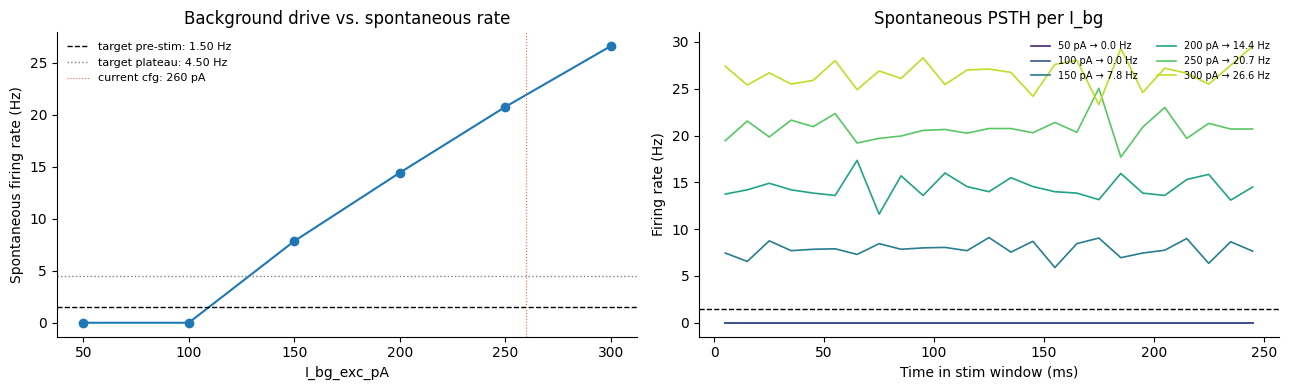


Target rate: 1.50 Hz
→ Suggested I_bg_exc_pA: ~109.6 pA  (currently 260.0)

To apply, uncomment the next two lines, then re-run the Build model + 2a cells:
# cfg.I_bg_exc_pA = 109.6
# model = RandomEINetwork(cfg)
Applied I_bg_exc_pA = 109.6; model rebuilt.


In [5]:
# Sweep range — edit as needed. Default starts well below the current 260 pA
# setting because the warning above suggests we're overshooting.
BG_VALUES_pA = [50.0, 100.0, 150.0, 200.0, 250.0, 300.0]

# Derive target baseline / plateau inline so this cell is independent of the
# init cell below. Using very-early bins for baseline and the late tail
# (post-peak second half) for the steady-state plateau.
_peak_idx_bg          = int(np.argmax(target_hz))
_post_peak_bg         = target_hz[_peak_idx_bg:]
target_plateau_hz     = float(np.median(_post_peak_bg[len(_post_peak_bg) // 2:]))
target_baseline       = float(target_hz[:max(1, _peak_idx_bg // 3)].min())
TARGET_BG_HZ          = float(target_baseline)   # use pre-stim target rate as the goal

# Zero-amplitude waveform → pure spontaneous activity in the stim window
_zero_wf = SplitGaussianWaveform(amplitude=0.0, mu=100.0,
                                  sigma_rise=20.0, sigma_fall=40.0, baseline=0.0)

_original_bg = float(cfg.I_bg_exc_pA)
_sweep_results = []   # list of (bg_pA, mean_rate_hz, psth_hz)

import time as _time
for _bg in BG_VALUES_pA:
    cfg.I_bg_exc_pA = float(_bg)
    _model_tmp = RandomEINetwork(cfg)
    _t0 = _time.time()
    _out = _model_tmp.run(_zero_wf)
    _psth_hz = _out['psth_exc'] / (bin_size_ms / 1000.0)
    _rate    = float(_psth_hz.mean())
    _sweep_results.append((_bg, _rate, _psth_hz, _out['t_psth_ms']))
    print(f'  I_bg_exc = {_bg:>6.1f} pA  →  spontaneous rate {_rate:>6.2f} Hz   '
          f'({_time.time() - _t0:.1f} s)')

# Restore original (we'll print a recommendation; user applies it explicitly)
cfg.I_bg_exc_pA = _original_bg

_bgs_arr   = np.array([r[0] for r in _sweep_results])
_rates_arr = np.array([r[1] for r in _sweep_results])

# ── Plot ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ax = axes[0]
ax.plot(_bgs_arr, _rates_arr, 'o-', color='tab:blue', lw=1.5)
ax.axhline(TARGET_BG_HZ, color='k', lw=1, ls='--',
           label=f'target pre-stim: {TARGET_BG_HZ:.2f} Hz')
ax.axhline(target_plateau_hz, color='grey', lw=1, ls=':',
           label=f'target plateau: {target_plateau_hz:.2f} Hz')
ax.axvline(_original_bg, color='tomato', lw=0.8, ls=':',
           label=f'current cfg: {_original_bg:.0f} pA')
ax.set_xlabel('I_bg_exc_pA')
ax.set_ylabel('Spontaneous firing rate (Hz)')
ax.set_title('Background drive vs. spontaneous rate')
ax.legend(frameon=False, fontsize=8)
ax.spines[['top', 'right']].set_visible(False)

ax = axes[1]
_cmap = plt.cm.viridis(np.linspace(0.1, 0.9, len(_sweep_results)))
for (bg, rate, psth, t_ms_arr), color in zip(_sweep_results, _cmap):
    ax.plot(t_ms_arr, psth, color=color, lw=1.2,
            label=f'{bg:.0f} pA → {rate:.1f} Hz')
ax.axhline(TARGET_BG_HZ, color='k', lw=1, ls='--')
ax.set_xlabel('Time in stim window (ms)')
ax.set_ylabel('Firing rate (Hz)')
ax.set_title('Spontaneous PSTH per I_bg')
ax.legend(frameon=False, fontsize=7, ncol=2)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
plt.show()

# ── Recommendation ──────────────────────────────────────────────────────
print(f'\nTarget rate: {TARGET_BG_HZ:.2f} Hz')
if _rates_arr.min() <= TARGET_BG_HZ <= _rates_arr.max():
    # Monotonicity is not guaranteed in recurrent nets, but usually rate grows with I_bg
    _order = np.argsort(_rates_arr)
    _suggested_bg = float(np.interp(TARGET_BG_HZ, _rates_arr[_order], _bgs_arr[_order]))
    print(f'→ Suggested I_bg_exc_pA: ~{_suggested_bg:.1f} pA  '
          f'(currently {_original_bg:.1f})')
    print('\nTo apply, uncomment the next two lines, then re-run the Build model + 2a cells:')
    print(f'# cfg.I_bg_exc_pA = {_suggested_bg:.1f}')
    print('# model = RandomEINetwork(cfg)')
else:
    if _rates_arr.min() > TARGET_BG_HZ:
        print(f'→ All swept values give rates above the target '
              f'({_rates_arr.min():.2f}–{_rates_arr.max():.2f} Hz). '
              f'Extend BG_VALUES_pA below {BG_VALUES_pA[0]:.0f} pA.')
    else:
        print(f'→ All swept values give rates below the target '
              f'({_rates_arr.min():.2f}–{_rates_arr.max():.2f} Hz). '
              f'Extend BG_VALUES_pA above {BG_VALUES_pA[-1]:.0f} pA.')

# ── Auto-apply (commented out) ─────────────────────────────────────────
# Uncomment these two lines to apply the suggested value automatically,
# then re-run the 2b init cell (no need to re-run Build model — done here).
cfg.I_bg_exc_pA = _suggested_bg
model = RandomEINetwork(cfg)
print(f'Applied I_bg_exc_pA = {cfg.I_bg_exc_pA:.1f}; model rebuilt.')
fig.savefig(output_dir / f'{SOURCE}_{TARGET_LAYER}_bg_sweep.png', dpi=300)

## 2b. Derive a sensible initial waveform from the target

Reads the peak time, peak height, and rise/fall half-widths off the target
PSTH and uses them to seed the `SplitGaussianWaveform`. Then runs the model
once with this init and overlays the simulated PSTH on the target — a
pre-flight check before launching the optimiser.

If the initial simulated peak is dramatically higher or lower than the
target peak, the cell prints a suggested `amplitude` rescaling so you can
land in the right ballpark without burning optimiser calls.


In [ ]:
# ── 1. Target-shape analysis ────────────────────────────────────────────
_peak_idx        = int(np.argmax(target_hz))
target_peak_time = float(t_target_ms[_peak_idx])
target_peak_hz   = float(target_hz[_peak_idx])
# 'plateau' = median of the post-peak second-half — proxy for steady state
_post_peak        = target_hz[_peak_idx:]
target_plateau_hz = float(np.median(_post_peak[len(_post_peak)//2:]))
target_baseline   = float(target_hz[:max(1, _peak_idx // 3)].min())

# Rise/fall half-widths: time from 50%-of-peak (above plateau) to the peak
_half_max = (target_plateau_hz + target_peak_hz) / 2
_rise_t   = t_target_ms[:_peak_idx + 1]
_rise_h   = target_hz[:_peak_idx + 1]
_rise_50  = float(np.interp(_half_max, _rise_h, _rise_t))
sigma_rise_est = max(target_peak_time - _rise_50, 5.0)

_fall_t   = t_target_ms[_peak_idx:]
_fall_h   = target_hz[_peak_idx:]
_fall_50  = float(np.interp(_half_max, _fall_h[::-1], _fall_t[::-1]))
sigma_fall_est = max(_fall_50 - target_peak_time, 5.0)

print('Target-shape readout')
print(f'  peak           : {target_peak_hz:.2f} Hz at t = {target_peak_time:.0f} ms')
print(f'  plateau (late) : {target_plateau_hz:.2f} Hz')
print(f'  pre-stim       : {target_baseline:.2f} Hz')
print(f'  σ_rise (50%→peak): ~{sigma_rise_est:.1f} ms')
print(f'  σ_fall (peak→50%): ~{sigma_fall_est:.1f} ms')

# ── 2. Build the initial waveform ────────────────────────────────────────
# Amplitude and baseline units depend on USE_POWER_MODE:
#   True  → mW at source  (bounds up to MAX_POWER_MW ≈ 4.55 mW)
#   False → dimensionless [0, 1]
if USE_POWER_MODE:
    _amp_init   = MAX_POWER_MW * 0.25   # start at 25% of max power
    _base_max   = MAX_POWER_MW * 0.25   # baselines up to 25% of max
    _amp_label  = 'mW'
else:
    _amp_init   = 0.05
    _base_max   = 0.3
    _amp_label  = 'AU'

init_waveform = AsymBaselineSplitGaussianWaveform(
    amplitude     = _amp_init,
    mu            = target_peak_time,
    sigma_rise    = sigma_rise_est,
    sigma_fall    = sigma_fall_est,
    baseline_rise = 0.0,
    baseline_fall = 0.0,
)
print(f'\nInitial waveform ({_amp_label}): {init_waveform}')

# ── 3. Run the network once with this init and compare to target ─────────
_init_result   = model.run(init_waveform)
_init_psth     = _init_result['psth_exc']
_init_hz       = _init_psth / (bin_size_ms / 1000.0)
_t_psth_ms     = _init_result['t_psth_ms']
_t_stim_ms_arr = _init_result['t_stim_ms']

init_peak_hz  = float(_init_hz.max())
init_plateau  = float(np.median(_init_hz[len(_init_hz)//2:]))

fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))

ax = axes[0]
ax.plot(_t_stim_ms_arr, init_waveform(_t_stim_ms_arr), color='tomato', lw=2,
        label='Initial envelope')
ax.axvline(target_peak_time, color='k', lw=0.8, ls=':', label=f'target peak ({target_peak_time:.0f} ms)')
ax.axhline(0, color='k', lw=0.5, ls=':')
ax.set_xlabel('Time in stim window (ms)')
ax.set_ylabel(f'Amplitude ({_amp_label})')
ax.set_title('Initial waveform')
ax.legend(frameon=False, fontsize=8)
ax.spines[['top', 'right']].set_visible(False)

ax = axes[1]
if not np.isnan(target_err).all():
    ax.fill_between(t_target_ms, target_hz - target_err, target_hz + target_err,
                    color='k', alpha=0.2)
ax.plot(t_target_ms, target_hz, color='k', lw=1.8, label='Target')
ax.plot(_t_psth_ms, _init_hz, color='tomato', lw=1.5, ls='--', label='Initial SNN')
ax.set_xlabel('Time in stim window (ms)')
ax.set_ylabel('Firing rate (Hz)')
ax.set_title('Target vs. initial SNN PSTH')
ax.legend(frameon=False, fontsize=8)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
plt.show()

# ── 4. Diagnostic & adjustment suggestion ────────────────────────────────
print(f'\nInitial SNN peak     : {init_peak_hz:.2f} Hz')
print(f'Initial SNN plateau  : {init_plateau:.2f} Hz')
print(f'Target peak          : {target_peak_hz:.2f} Hz')
print(f'Target plateau       : {target_plateau_hz:.2f} Hz')

_peak_excess   = init_peak_hz  - init_plateau
_target_excess = target_peak_hz - target_plateau_hz
if _peak_excess > 0.1 and _target_excess > 0.1:
    _ratio = _target_excess / _peak_excess
    print(f'\nPeak-above-plateau ratio (target/init): {_ratio:.2f}×')
    if abs(_ratio - 1.0) > 0.3:
        suggested = init_waveform.amplitude * _ratio
        direction = 'raising' if _ratio > 1 else 'lowering'
        print(f'  → consider {direction} amplitude to ~{suggested:.3f} {_amp_label} before optimising')
    else:
        print('  → init amplitude is in a sensible range.')
if init_plateau > target_peak_hz:
    print("\n⚠ The network's baseline firing rate is already higher than the target peak.\n"
          "  Lower cfg.I_bg_exc_pA first (use the bg-sweep cell).")

# ── 5. Bounds for the optimiser ──────────────────────────────────────────
_amp_max = MAX_POWER_MW if USE_POWER_MODE else 1.0
init_bounds = [
    (0.0,  _amp_max),
    (5.0,  STIM_DUR_MS - 5.0),
    (2.0,  100.0),
    (2.0,  200.0),
    (0.0,  _base_max),
    (0.0,  _base_max),
]
_bound_names = ['amplitude', 'mu', 'sigma_rise', 'sigma_fall', 'baseline_rise', 'baseline_fall']
_units       = [_amp_label, 'ms', 'ms', 'ms', _amp_label, _amp_label]
print(f'\nBounds for optimiser:')
for name, unit, (lo, hi) in zip(_bound_names, _units, init_bounds):
    print(f'  {name:<14}: [{lo:>6.3f}, {hi:>6.3f}] {unit}')
fig.savefig(output_dir / f'{SOURCE}_{TARGET_LAYER}_initial_waveform.png', dpi=300)

## 3. Define objective function

In [ ]:
PENALTY_WEIGHT   = 1e4
USE_PEAK_WEIGHTS = False   # set True to weight the MSE more heavily around the peak

PEAK_WEIGHT   = 5.0   # max weight at peak relative to tails
PEAK_SIGMA_MS = 30.0  # width of the emphasis window (ms)

_peak_t = float(t_target_ms[np.argmax(target_psth)])
if USE_PEAK_WEIGHTS:
    _w_raw   = 1.0 + (PEAK_WEIGHT - 1.0) * np.exp(
        -0.5 * ((t_target_ms - _peak_t) / PEAK_SIGMA_MS) ** 2
    )
    _weights = _w_raw / _w_raw.mean()
    print(f"Peak-weighting ON: centre={_peak_t:.0f} ms, sigma={PEAK_SIGMA_MS:.0f} ms, "
          f"max={_weights.max():.2f}×, min={_weights.min():.2f}×")
else:
    _weights = np.ones(len(target_psth))
    print("Peak-weighting OFF: uniform MSE")

_scale = target_psth.max() - target_psth.min() + 1e-9

def psth_mse(waveform: AsymBaselineSplitGaussianWaveform) -> float:
    result = model.run(waveform)
    pred   = result["psth_exc"]

    loss = float(np.mean(_weights * ((pred - target_psth) / _scale) ** 2))

    t_stim_ms = result["t_stim_ms"]
    y = waveform(t_stim_ms)
    loss += PENALTY_WEIGHT * float(np.mean(np.clip(-y, 0, None) ** 2))

    return loss

## 4. Run optimisation

Initial guess is informed by the known VISp response shape:
fast rise peaking ~40 ms, slow decay over ~100 ms.

In [ ]:
# Uses init_waveform and init_bounds from the previous cell.
# Bounds keep amplitude ≥ 0 and baseline ≥ 0 so the envelope stays physical
# without relying on the soft penalty in the objective.

# Sanity check: PSTH bin counts on target and model must match
_check = model.run(init_waveform)
assert len(_check['psth_exc']) == len(target_psth), (
    f"PSTH length mismatch: model={len(_check['psth_exc'])}, target={len(target_psth)}. "
    f"Check cfg.t_stim_ms and cfg.psth_bin_ms."
)
print(f"Grid check OK — {len(target_psth)} bins")

# patience: stop after this many calls with no relative improvement > min_improvement.
# Set to None to disable early stopping and rely entirely on maxiter/fatol/xatol.
result_waveform, opt = init_waveform.optimise(
    psth_mse,
    method='Nelder-Mead',
    bounds=init_bounds,
    verbose=True,
    log_every=10,
    patience=50,
    min_improvement=1e-4,
    options={'maxiter': 300, 'xatol': 1e-4, 'fatol': 1e-7, 'adaptive': True},
)

t_stim_ms = _check['t_stim_ms']
print(f"\nMin waveform value : {result_waveform(t_stim_ms).min():.4f}  (should be ≥ 0)")
print(f"Optimised waveform : {result_waveform}")

## 5. Compare results

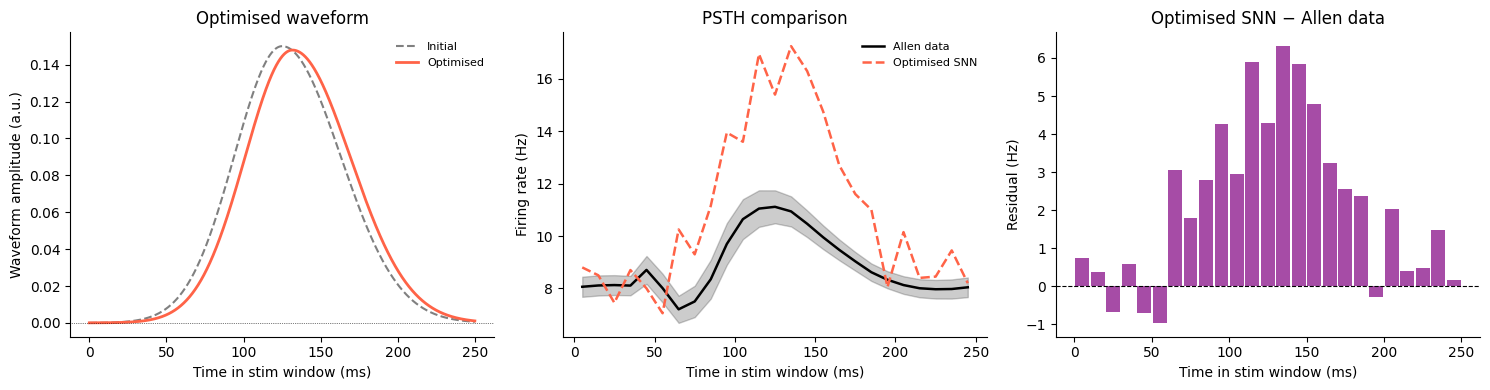

MSE — initial: 1.1153e+01   optimised: 9.1882e+00   improvement: 1.2×


In [ ]:
opt_result = model.run(result_waveform)
opt_psth   = opt_result["psth_exc"]
t_psth_ms  = opt_result["t_psth_ms"]

# convert model output back to Hz for comparison
opt_hz  = opt_psth  / (bin_size_ms / 1000.0)
init_hz = model.run(init_waveform)["psth_exc"] / (bin_size_ms / 1000.0)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# waveforms
ax = axes[0]
ax.plot(t_stim_ms, init_waveform(t_stim_ms),   color="grey",     lw=1.5, ls="--", label="Initial")
ax.plot(t_stim_ms, result_waveform(t_stim_ms), color="tomato",   lw=2,             label="Optimised")
ax.axhline(0, color="k", lw=0.5, ls=":")
ax.set_xlabel("Time in stim window (ms)")
ax.set_ylabel("Waveform amplitude (a.u.)")
ax.set_title("Optimised waveform")
ax.legend(frameon=False, fontsize=8)
ax.spines[["top", "right"]].set_visible(False)

# PSTH comparison
ax = axes[1]
ax.fill_between(t_target_ms, target_hz - target_err, target_hz + target_err,
                color='k', alpha=0.2)
ax.plot(t_target_ms, target_hz, color="k",      lw=1.8, label="Allen data")
ax.plot(t_psth_ms,   opt_hz,    color="tomato", lw=1.8, ls="--", label="Optimised SNN")
ax.set_xlabel("Time in stim window (ms)")
ax.set_ylabel("Firing rate (Hz)")
ax.set_title("PSTH comparison")
ax.legend(frameon=False, fontsize=8)
ax.spines[["top", "right"]].set_visible(False)

# residuals
ax = axes[2]
ax.bar(t_psth_ms, opt_hz - target_hz,
       width=bin_size_ms * 0.9, color="purple", alpha=0.7)
ax.axhline(0, color="k", lw=0.8, ls="--")
ax.set_xlabel("Time in stim window (ms)")
ax.set_ylabel("Residual (Hz)")
ax.set_title("Optimised SNN − Allen data")
ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()

fig.savefig(output_dir / f'{SOURCE}_{TARGET_LAYER}_optimised_waveform.png', dpi=300)
mse_init = np.mean((init_hz  - target_hz) ** 2)
mse_opt  = np.mean((opt_hz   - target_hz) ** 2)
print(f"MSE — initial: {mse_init:.4e}   optimised: {mse_opt:.4e}   "
      f"improvement: {mse_init / mse_opt:.1f}×")


In [ ]:
# ── Raster + fine-bin bar PSTH ────────────────────────────────────────────
# Uses spike times already in opt_result — no extra simulation.
N_RASTER    = 200   # how many exc neurons to show in raster
FINE_BIN_MS = 5.0   # bin size for display PSTH (finer than optimisation bins)

# Excitatory spike times relative to stim onset
_exc_mask    = opt_result['spike_indices'] < cfg.N_exc
_exc_times   = opt_result['spike_times_ms'][_exc_mask] - cfg.t_pre_ms
_exc_neurons = opt_result['spike_indices'][_exc_mask]

# Restrict to stim window
_win         = (_exc_times >= 0) & (_exc_times <= STIM_DUR_MS)
_st, _si     = _exc_times[_win], _exc_neurons[_win]

# Fine-bin PSTH from raw spikes
_fine_edges         = np.arange(0, STIM_DUR_MS + FINE_BIN_MS, FINE_BIN_MS)
_fine_counts, _     = np.histogram(_st, bins=_fine_edges)
_fine_hz            = (_fine_counts / cfg.N_exc) / (FINE_BIN_MS / 1000.0)
_fine_t             = 0.5 * (_fine_edges[:-1] + _fine_edges[1:])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Raster
ax = axes[0]
_rm = _si < N_RASTER
ax.scatter(_st[_rm], _si[_rm], s=1.5, color='k', alpha=0.4, linewidths=0)
ax.set_xlim(0, STIM_DUR_MS)
ax.set_ylim(0, N_RASTER)
ax.set_xlabel('Time from stim onset (ms)')
ax.set_ylabel('Neuron index')
ax.set_title(f'Raster — first {N_RASTER} exc neurons (optimised)')
ax.spines[['top', 'right']].set_visible(False)

# Fine-bin bar PSTH vs target
ax = axes[1]
ax.bar(_fine_t, _fine_hz, width=FINE_BIN_MS * 0.9,
       color='tomato', alpha=0.7, label=f'SNN ({FINE_BIN_MS:.0f} ms bins)')
if not np.isnan(target_err).all():
    ax.fill_between(t_target_ms, target_hz - target_err, target_hz + target_err,
                    color='k', alpha=0.2)
ax.plot(t_target_ms, target_hz, color='k', lw=1.8, label='Allen data')
ax.set_xlabel('Time from stim onset (ms)')
ax.set_ylabel('Firing rate (Hz)')
ax.set_title('PSTH — optimised SNN vs target')
ax.legend(frameon=False, fontsize=8)
ax.spines[['top', 'right']].set_visible(False)

fig.tight_layout()
plt.show()
fig.savefig(output_dir / f'{SOURCE}_{TARGET_LAYER}_raster_psth.png', dpi=300)

In [ ]:
# ── Multi-run mean ± SEM PSTH ─────────────────────────────────────────────
# Each run uses a different seed. Toggle each source of randomness below.
N_RUNS    = 20    # number of stochastic runs — ~5–10 s each
SEED_BASE = 1000  # seeds will be SEED_BASE, SEED_BASE+1, ...

VARY_INIT_V       = True   # vary initial membrane voltages across runs
VARY_CONNECTIVITY = True   # vary synaptic connectivity pattern across runs
VARY_WEIGHTS      = True   # vary synaptic weight values across runs

_all_opt  = []
_all_fine = []

_fine_edges_mr = np.arange(0, STIM_DUR_MS + FINE_BIN_MS, FINE_BIN_MS)
_fine_t_mr     = 0.5 * (_fine_edges_mr[:-1] + _fine_edges_mr[1:])

_vary_str = ', '.join(
    s for s, v in [('init_v', VARY_INIT_V), ('connectivity', VARY_CONNECTIVITY),
                   ('weights', VARY_WEIGHTS)] if v
) or 'none'
print(f"Running {N_RUNS} simulations — varying: {_vary_str}")

for _i in range(N_RUNS):
    _r = model.run(result_waveform, seed=SEED_BASE + _i,
                   vary_init_v=VARY_INIT_V,
                   vary_connectivity=VARY_CONNECTIVITY,
                   vary_weights=VARY_WEIGHTS)
    _all_opt.append(_r['psth_exc'])

    _exc_m  = _r['spike_indices'] < cfg.N_exc
    _et     = _r['spike_times_ms'][_exc_m] - cfg.t_pre_ms
    _win    = (_et >= 0) & (_et <= STIM_DUR_MS)
    _cnt, _ = np.histogram(_et[_win], bins=_fine_edges_mr)
    _all_fine.append(_cnt / cfg.N_exc / (FINE_BIN_MS / 1000.0))

    if (_i + 1) % 5 == 0:
        print(f"  {_i + 1}/{N_RUNS}")

_opt_arr  = np.stack(_all_opt)
_fine_arr = np.stack(_all_fine)

mean_opt_hz  = _opt_arr.mean(0)  / (bin_size_ms / 1000.0)
sem_opt_hz   = _opt_arr.std(0)   / (bin_size_ms / 1000.0) / np.sqrt(N_RUNS)
mean_fine_hz = _fine_arr.mean(0)
sem_fine_hz  = _fine_arr.std(0)  / np.sqrt(N_RUNS)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
for _run_hz in _opt_arr / (bin_size_ms / 1000.0):
    ax.plot(t_psth_ms, _run_hz, color='tomato', lw=0.7, alpha=0.2)
ax.fill_between(t_psth_ms, mean_opt_hz - sem_opt_hz, mean_opt_hz + sem_opt_hz,
                color='tomato', alpha=0.35)
ax.plot(t_psth_ms, mean_opt_hz, color='tomato', lw=2,
        label=f'SNN mean ± SEM (n={N_RUNS})')
if not np.isnan(target_err).all():
    ax.fill_between(t_target_ms, target_hz - target_err, target_hz + target_err,
                    color='k', alpha=0.15)
ax.plot(t_target_ms, target_hz, color='k', lw=1.8, label='Allen data')
ax.set_xlabel('Time from stim onset (ms)')
ax.set_ylabel('Firing rate (Hz)')
ax.set_title(f'PSTH — {bin_size_ms:.0f} ms bins  [varying: {_vary_str}]')
ax.legend(frameon=False, fontsize=8)
ax.spines[['top', 'right']].set_visible(False)

ax = axes[1]
for _run_hz in _fine_arr:
    ax.plot(_fine_t_mr, _run_hz, color='tomato', lw=0.7, alpha=0.2)
ax.fill_between(_fine_t_mr, mean_fine_hz - sem_fine_hz, mean_fine_hz + sem_fine_hz,
                color='tomato', alpha=0.35)
ax.plot(_fine_t_mr, mean_fine_hz, color='tomato', lw=2,
        label=f'SNN mean ± SEM (n={N_RUNS})')
if not np.isnan(target_err).all():
    ax.fill_between(t_target_ms, target_hz - target_err, target_hz + target_err,
                    color='k', alpha=0.15)
ax.plot(t_target_ms, target_hz, color='k', lw=1.8, label='Allen data')
ax.set_xlabel('Time from stim onset (ms)')
ax.set_ylabel('Firing rate (Hz)')
ax.set_title(f'Fine-bin PSTH — {FINE_BIN_MS:.0f} ms bins  [varying: {_vary_str}]')
ax.legend(frameon=False, fontsize=8)
ax.spines[['top', 'right']].set_visible(False)

fig.tight_layout()
plt.show()
fig.savefig(output_dir / f'{SOURCE}_{TARGET_LAYER}_multirun_psth.png', dpi=300)

mse_mean = float(np.mean((mean_opt_hz - target_hz) ** 2))
print(f"\nMSE — single run: {mse_opt:.4e}   mean of {N_RUNS} runs: {mse_mean:.4e}")

In [ ]:
# save results for later analysis
_save_dict = {
    'source': SOURCE,
    'target_layer': TARGET_LAYER,
    'use_rf_filter': USE_RF_FILTER,
    'stim_dur_ms': STIM_DUR_MS,
    'target_t_ms': t_target_ms,
    'target_hz': target_hz,
    'target_err': target_err,
    # waveform objects
    'init_waveform': init_waveform,
    'opt_waveform': result_waveform,
    # explicit init params for easy inspection without instantiating the class
    'init_params': {k: float(v) for k, v in zip(
        ['amplitude', 'mu', 'sigma_rise', 'sigma_fall', 'baseline_rise', 'baseline_fall'],
        init_waveform.to_params(),
    )},
    # single-run PSTHs
    'init_psth_hz': init_hz,
    'opt_psth_hz': opt_hz,
    'psth_bin_ms': bin_size_ms,
    'mse_init': mse_init,
    'mse_opt': mse_opt,
    # multi-run results (may not exist if that cell wasn't run)
    **({'n_runs': N_RUNS,
        'seed_base': SEED_BASE,
        'multirun_psth_hz': _opt_arr / (bin_size_ms / 1000.0),
        'multirun_mean_hz': mean_opt_hz,
        'multirun_sem_hz': sem_opt_hz,
        'mse_mean': mse_mean,
    } if 'mean_opt_hz' in dir() else {}),
}
_save_path = output_dir / f'{SOURCE}_{TARGET_LAYER}_optimisation_result.pkl'
with open(_save_path, 'wb') as f:
    pickle.dump(_save_dict, f)
print(f"Saved to {_save_path}")
print(f"Keys: {list(_save_dict.keys())}")